In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# 11 — Optional: reuse weights, spend more computation

This optional mechanism lab applies the same causal decoder block repeatedly:
$h_{r+1}=F_\theta(h_r)$.
It contrasts one stored parameter set with several block applications. It does not implement an adaptive router, reproduce a published training recipe, or claim that untrained repetition improves reasoning.

Further reading: [Recurrent Depth Approach, v2](https://arxiv.org/abs/2502.05171v2) and [Mixture-of-Recursions, v3](https://arxiv.org/abs/2507.10524v3). The first studies repeated latent computation; the second adds adaptive token-level recursion. Our fixed two-pass toy is deliberately narrower than either paper.

## How to work through this notebook

Run setup once. At each checkpoint, write a prediction and try the small implementation before reading its adjacent reference solution. All reference cells run unchanged from top to bottom; exercise cells contain safe, optional starting points. Numerical checks use CPU float64 unless explicitly noted. Agent-verified reference execution is separate from your learning progress.

In [2]:
from pathlib import Path
import sys, copy, math, inspect
from dataclasses import replace
import torch
from torch import nn
from torch.nn import functional as F
root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/dongxi_llms/decoder_lab.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook from inside the Dongxi_LLMs repository")
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
from dongxi_llms.decoder_lab import (
    DecoderConfig, TinyDecoder, DecoderBlock, MultiHeadAttention, MLP, RMSNorm,
    layer_norm, rms_norm, rope, attend, parameter_count, analytical_parameters,
    cost_estimate, teaching_batch, next_token_loss, fit_one_batch)
torch.set_num_threads(1)
torch.manual_seed(505)
DTYPE = torch.float64
def close(actual, expected, atol=1e-10, rtol=1e-8):
    torch.testing.assert_close(actual, expected, atol=atol, rtol=rtol)
print("CPU reference environment:", torch.__version__)


CPU reference environment: 2.14.1+cpu


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from dongxi_llms import decoder_visuals as viz
def show_visual(figure):
    display(figure)
    plt.close(figure)


## Architecture map — your location in the model

The highlighted stage is this lesson’s focus. B = batch, T = positions, D = model width, V = vocabulary size. This is a structural map, not measured activations or runtime. The baseline route adds learned position embeddings before the blocks.

![Architecture map — your location in the model. The highlighted stage is this lesson’s focus. B = batch, T = positions, D = model width, V = vocabulary size. This is a structural map, not measured activations or runtime. The baseline route adds learned position embeddings before the blocks.](../figures/chapter-05/day-07-01_recurrent_depth-architecture-map.png)

*Saved architecture schematic. The following cell regenerates it; it does not execute or train a model.*

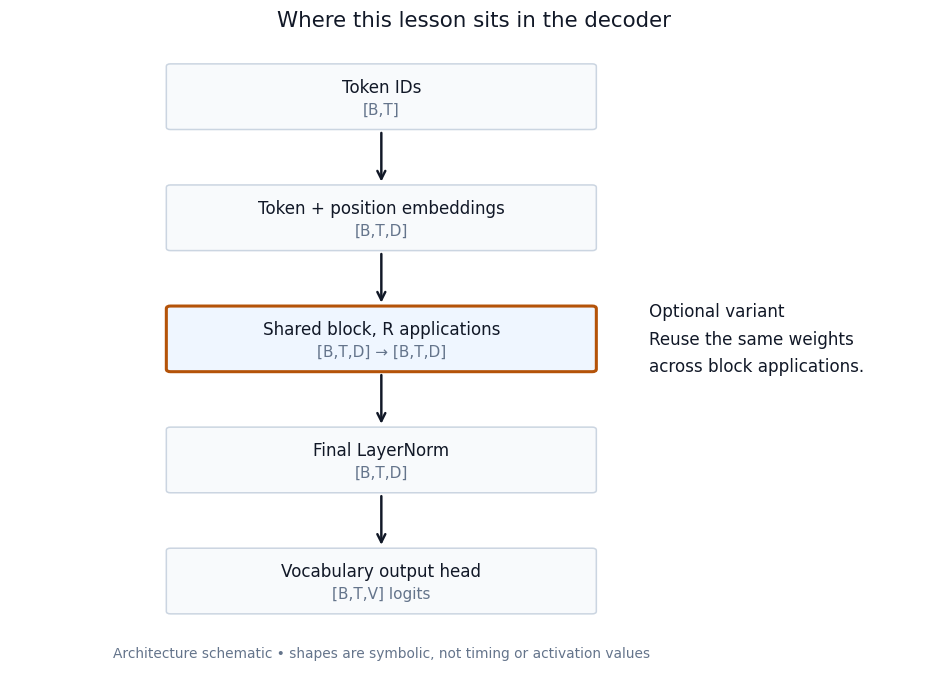

In [4]:
from dongxi_llms import decoder_architecture as architecture
show_visual(architecture.model_map(focus='recurrence', modern=False))

## Reuse parameters without reusing the same hidden state

The same parameter set θ feeds both applications, while h₀, h₁, and h₂ differ. This is a fixed-sharing schematic, not an adaptive router or a claim that the notebook implements a full recurrent inference system.

![Reuse parameters without reusing the same hidden state. The same parameter set θ feeds both applications, while h₀, h₁, and h₂ differ. This is a fixed-sharing schematic, not an adaptive router or a claim that the notebook implements a full recurrent inference system.](../figures/chapter-05/day-07-01_recurrent_depth-architecture-detail.png)

*Saved architecture schematic. The following cell regenerates it; it does not execute or train a model.*

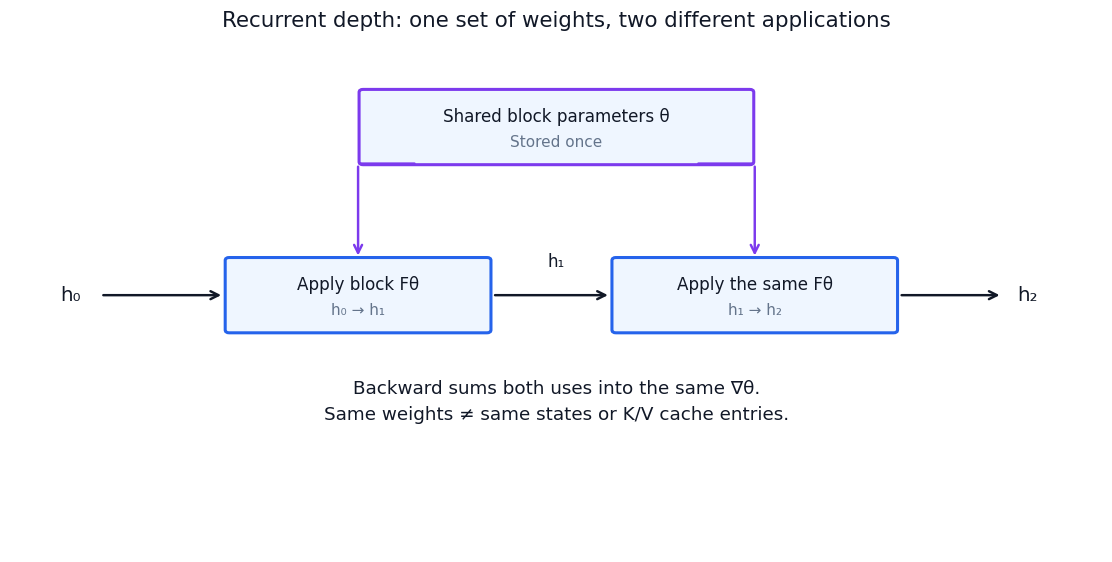

In [5]:
show_visual(architecture.recurrence_detail())

## 1. Apply one block twice

Use one module instance twice. Compare with two independent copies initialized to exactly the same values. Do equal outputs imply equal storage?

**Your prediction:** _Write it here before running the reference._

In [6]:
block = DecoderBlock(DecoderConfig()).double()
first, second = copy.deepcopy(block), copy.deepcopy(block)
x = torch.randn(2, 6, 16, dtype=DTYPE)
# Your implementation: shared_output = ...; copied_output = ...

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [7]:
shared_output = block(block(x)[0])[0]
copied_output = second(first(x)[0])[0]
close(shared_output, copied_output)
shared_container = nn.ModuleList([block, block])
copied_container = nn.ModuleList([first, second])
assert parameter_count(copied_container) == 2*parameter_count(shared_container)
print("Shared / independent stored parameters:",
      parameter_count(shared_container), parameter_count(copied_container))
print("Both execute two block applications.")

Shared / independent stored parameters: 2160 4320
Both execute two block applications.


### Why this works

The two graphs initially compute the same function because their weights match. The shared graph has one trainable parameter set; the independent graph has two. Equal initialized values are not the same as weight tying.

## 2. Follow gradients through both applications

Will a shared weight receive feedback only from its last use? Compare its gradient to the sum of the corresponding independent-copy gradients.

**Your prediction:** _Write it here before running the reference._

In [8]:
# Your implementation: backward through the two graphs and compare gradients.

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [9]:
shared_output.square().mean().backward()
copied_output.square().mean().backward()
errors = []
for shared, a, b in zip(block.parameters(), first.parameters(), second.parameters()):
    close(shared.grad, a.grad+b.grad)
    errors.append(float((shared.grad-a.grad-b.grad).abs().max()))
print("Shared-gradient sum max error:", max(errors))

Shared-gradient sum max error: 1.3877787807814457e-17


### Why this works

Backward traverses both uses of the same parameter and accumulates both contributions. After an optimizer update, independent copies can diverge while shared weights remain tied.

## 3. Separate parameter matching from compute matching

Compare one shared pass, two shared passes, and two independent blocks. What changes when you hold storage constant versus block applications constant?

**Your prediction:** _Write it here before running the reference._

In [10]:
# State a fair comparison question before printing the ledger.

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [11]:
stored = parameter_count(block)
ledger = [
    {"variant":"one block, one pass", "stored_block_parameters":stored, "block_applications":1},
    {"variant":"one block, two passes", "stored_block_parameters":stored, "block_applications":2},
    {"variant":"two independent blocks", "stored_block_parameters":2*stored, "block_applications":2},
]
print(*ledger, sep="\n")
with torch.no_grad():
    state, norms = x, []
    for _ in range(4):
        state = block(state)[0]
        norms.append(float(state.norm()))
    changed = x.clone(); changed[:, 4:] += 3
    original = block(block(x)[0])[0]
    perturbed = block(block(changed)[0])[0]
    close(original[:, :4], perturbed[:, :4])
print("State norms after 1–4 applications:", norms)

{'variant': 'one block, one pass', 'stored_block_parameters': 2160, 'block_applications': 1}
{'variant': 'one block, two passes', 'stored_block_parameters': 2160, 'block_applications': 2}
{'variant': 'two independent blocks', 'stored_block_parameters': 4320, 'block_applications': 2}
State norms after 1–4 applications: [13.87975923432469, 16.349842072238893, 20.523192432382142, 25.784482821623364]


### Why this works

One versus two shared passes is parameter-matched but not block-compute-matched. Two shared passes versus two equal-width independent blocks matches block arithmetic but not stored parameters. Neither guarantees equal measured latency or activation memory. The random-state norms do not measure reasoning quality.

### Visual explanation — See what weight sharing saves—and what it does not

One shared block used twice has the same stored parameters as one use, but two block applications. Two independent blocks have twice the storage in this comparison. This is not a quality or latency ranking.

The figure uses this lesson’s tensors. Rerun it after changing the preceding experiment.

![See what weight sharing saves—and what it does not. One shared block used twice has the same stored parameters as one use, but two block applications. Two independent blocks have twice the storage in this comparison. This is not a quality or latency ranking.](../figures/chapter-05/day-07-01_recurrent_depth-visual-recurrent-cost.png)

*Saved reference preview. The code below regenerates this figure from the current lesson state; it does not overwrite the preview.*

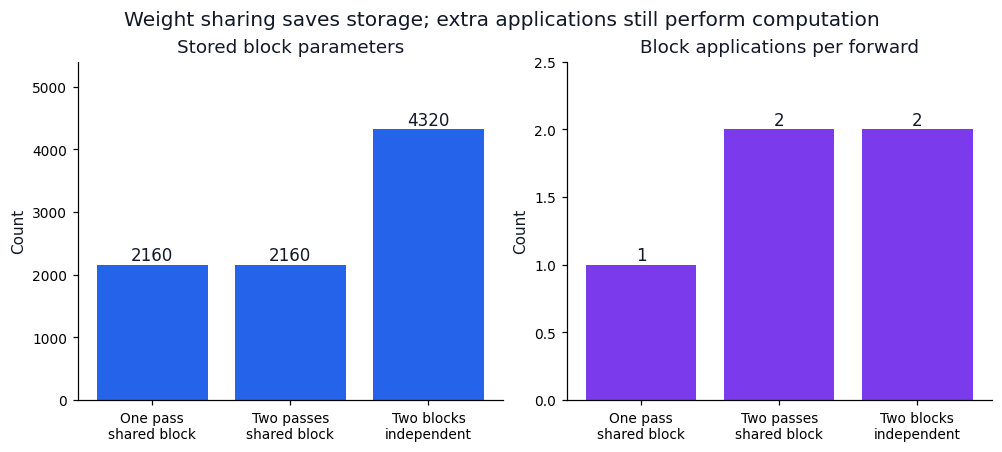

In [12]:
show_visual(viz.recurrence(ledger))

## 4. Test why identical weights do not imply identical KV states

Compare K/V from the first and second application of the same block. Can those cache entries be blindly aliased just because the projection matrices are shared?

**Your prediction:** _Write it here before running the reference._

In [13]:
# Predict whether the same block reads the same input states on both passes.

### Reference solution

Run after your attempt; compare the mechanism, not just the final numbers.

In [14]:
with torch.no_grad():
    h1, cache1, _ = block(x)
    h2, cache2, _ = block(h1)
difference = float((cache1[0]-cache2[0]).abs().max())
assert difference > 1e-8
print("First/second application K difference:", difference)

First/second application K difference: 0.6782059952908568


### Why this works

The second use sees an updated hidden state, so its projected K/V generally differ. A recurrent decoding implementation needs an explicit per-application cache policy; sharing weights does not automatically authorize sharing activations. This notebook does not implement recurrent cached generation.

### Visual explanation — See different states despite identical weights

These are K tensors for head 0, batch 0, from the first and second block applications. The changed inputs produce changed keys even though the projection matrix is shared.

The figure uses this lesson’s tensors. Rerun it after changing the preceding experiment.

![See different states despite identical weights. These are K tensors for head 0, batch 0, from the first and second block applications. The changed inputs produce changed keys even though the projection matrix is shared.](../figures/chapter-05/day-07-01_recurrent_depth-visual-recurrent-kv.png)

*Saved reference preview. The code below regenerates this figure from the current lesson state; it does not overwrite the preview.*

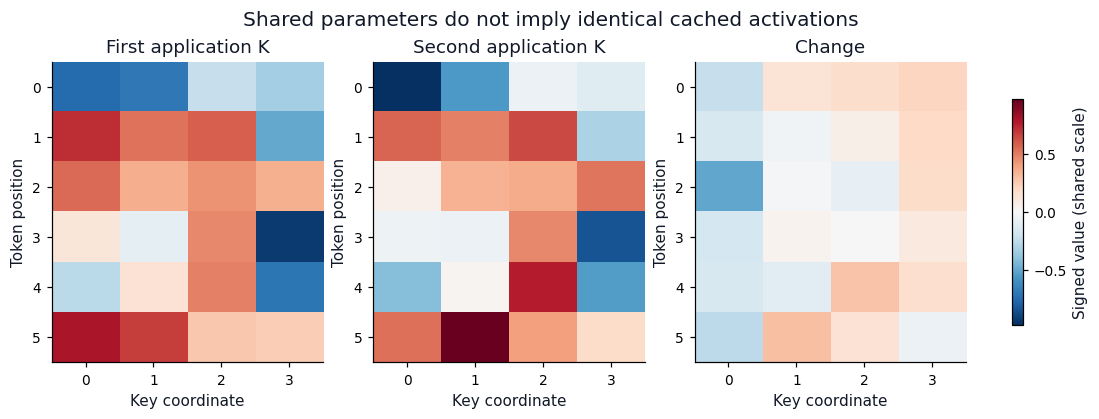

In [15]:
show_visual(viz.matrices([cache1[0][0,0], cache2[0][0,0], (cache2[0]-cache1[0])[0,0]], ['First application K', 'Second application K', 'Change'], 'Shared parameters do not imply identical cached activations', xlabel='Key coordinate', ylabel='Token position'))

## Takeaway and evidence boundary

Evidence boundary: fixed-depth sharing, forward identities, gradient accumulation, and causal invariance are checked. No training-quality comparison, learned early exit, wall-clock advantage, or claim about a closed model's architecture is made. X-LOOP-001 and CAND-ANIM-011 remain the article/animation reminders; rendering belongs on the Mac Studio.

Companion map: [Chapter 5 pathway](../day-05/README.md). Reusable source: [decoder_lab.py](../../src/dongxi_llms/decoder_lab.py). Record your explanation and remaining questions here; the notebook's existence does not mark the lesson complete.